In [2]:
import torch

In [5]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [6]:
%matplotlib inline
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [7]:
%matplotlib inline
import math
import time
import numpy as np

In [8]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

In [12]:
c = torch.zeros(n)
t = time.time()
for i in range(n):
    c[i] = a[i] + b[i]
    
f'{time.time() - t:.5f} sec'

'0.03973 sec'

In [11]:
t = time.time()
d = a + b
f'{time.time() - t:.5f} sec'

'0.00033 sec'

In [13]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 * (x - mu)**2 / sigma**2)

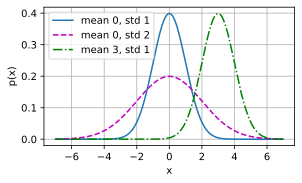

In [14]:
# Use NumPy again for visualization
x = np.arange(-7, 7, 0.01)
# Mean and standard deviation pairs
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
    ylabel='p(x)', figsize=(4.5, 2.5),
    legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

In [15]:
help(d2l)

Help on module d2l.torch in d2l:

NAME
    d2l.torch

CLASSES
    builtins.object
        Accumulator
        Animator
        Benchmark
        HyperParameters
            DataModule
                FashionMNIST
                MTFraEng
                SyntheticRegressionData
                TimeMachine
            HPOScheduler
                BasicScheduler
                SuccessiveHalvingScheduler
            HPOSearcher
                RandomSearcher
            HPOTuner
            Module(torch.nn.modules.module.Module, HyperParameters)
                Classifier
                    EncoderDecoder
                        Seq2Seq
                    LeNet
                    RNNLMScratch
                        RNNLM
                    SoftmaxRegression
                LinearRegression
                LinearRegressionScratch
                MultiHeadAttention
                RNN
                    GRU
                RNNScratch
            ProgressBoard
            SGD
         

In [16]:
?d2l

In [17]:
import sys
from io import StringIO

# Capture the help output
old_stdout = sys.stdout
sys.stdout = mystdout = StringIO()
help(d2l)  # Replace 'd2l' with your module name if needed
sys.stdout = old_stdout

# Get the captured text
help_text = mystdout.getvalue()

# Save to a text file (plain text)
with open('d2l_help.txt', 'w') as file:
    file.write(help_text)

# Alternatively, save as Markdown (wrapping in a code block for better rendering)
with open('d2l_help.md', 'w') as file:
    file.write('# Help for d2l module\n\n```\n' + help_text + '\n```')

# 3.4 Linear Regression Implementation from Scratch

In [19]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [ ]:
## 3.4.1 Defining the Model

In [20]:
class LinearRegressionScratch(d2l.Module): #@save
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [21]:
@d2l.add_to_class(LinearRegressionScratch) #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [22]:
## 3.4.2 Defining the Loss Function

In [23]:
@d2l.add_to_class(LinearRegressionScratch) #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

In [24]:
## 3.4.3 Defining the Optimization Algorithm

In [25]:
class SGD(d2l.HyperParameters): #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()
    def step(self):
        for param in self.params:
            param -= self.lr * param.grad
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [26]:
@d2l.add_to_class(LinearRegressionScratch) #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [27]:
## 3.4.4 Training

In [28]:
@d2l.add_to_class(d2l.Trainer) #@save
def prepare_batch(self, batch):
    return batch

In [29]:
@d2l.add_to_class(d2l.Trainer) #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0: # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1    

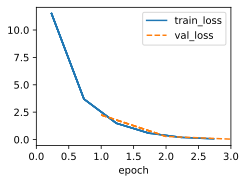

In [30]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [31]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.1344, -0.1503])
error in estimating b: tensor([0.1853])
